In [ ]:
!pip install tabpfn openpyxl -q

import os
os.environ["TABPFN_TOKEN"] = "API_KEY"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from tabpfn import TabPFNClassifier
import torch

In [ ]:
# %% Cell 1 -- load and prepare training data
train_df = pd.read_csv("/content/GSE98320.csv")

X_train = train_df.drop(columns=["sample_id", "diagnosis"])
y_train = train_df["diagnosis"]
sample_ids = train_df["sample_id"]

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

class_labels = sorted(y_train.unique())
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"Class labels (alphabetical): {class_labels}")

def make_model():
    return TabPFNClassifier(device=device, random_state=42)

Using device: cuda
Class labels (alphabetical): ['ABMR', 'NR', 'TCMR']


In [ ]:
# %% Cell 2 -- 10-fold OOF probabilities (same CV setup as your existing TabPFN run)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_r, y_r = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
ids_r = sample_ids.reset_index(drop=True)

oof_proba = np.zeros((len(y_r), len(class_labels)))
oof_pred = np.empty(len(y_r), dtype=object)

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_r, y_r)):
    model = make_model()
    model.fit(X_r.iloc[tr_idx], y_r.iloc[tr_idx])

    probas = model.predict_proba(X_r.iloc[te_idx])
    model_classes = list(model.classes_)
    for i, cls in enumerate(class_labels):
        if cls in model_classes:
            oof_proba[te_idx, i] = probas[:, model_classes.index(cls)]

    oof_pred[te_idx] = model.predict(X_r.iloc[te_idx])
    print(f"  fold {fold + 1}/10 done")

  fold 1/10 done
  fold 2/10 done
  fold 3/10 done
  fold 4/10 done
  fold 5/10 done
  fold 6/10 done
  fold 7/10 done
  fold 8/10 done
  fold 9/10 done
  fold 10/10 done


In [ ]:
# %% Cell 3 -- build the results dataframe with P_<class>, top/second prob, margin
results_df = pd.DataFrame({
    "sample_id": ids_r,
    "y_true": y_r,
    "y_pred": oof_pred,
})
for i, cls in enumerate(class_labels):
    results_df[f"P_{cls}"] = oof_proba[:, i]

sorted_proba = -np.sort(-oof_proba, axis=1)  # descending, per row
results_df["top_prob"] = sorted_proba[:, 0]
results_df["second_prob"] = sorted_proba[:, 1]
results_df["margin"] = results_df["top_prob"] - results_df["second_prob"]
results_df["correct"] = (results_df["y_true"] == results_df["y_pred"])

print(f"\nOverall OOF accuracy: {results_df['correct'].mean():.4f}")
print(f"Total errors: {(~results_df['correct']).sum()} of {len(results_df)}")


Overall OOF accuracy: 0.9153
Total errors: 100 of 1181


In [ ]:
# %% Cell 4 -- threshold comparison table
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25]
threshold_rows = []
total_errors = (~results_df["correct"]).sum()

for t in thresholds:
    ambiguous = results_df["margin"] < t
    n_ambiguous = ambiguous.sum()
    ambiguity_pct = n_ambiguous / len(results_df) * 100

    err_amb = (~results_df.loc[ambiguous, "correct"]).mean() * 100 if n_ambiguous > 0 else np.nan
    err_nonamb = (~results_df.loc[~ambiguous, "correct"]).mean() * 100 if (~ambiguous).sum() > 0 else np.nan

    errors_captured = (~results_df["correct"] & ambiguous).sum()
    errors_captured_pct = errors_captured / total_errors * 100 if total_errors > 0 else np.nan

    threshold_rows.append({
        "threshold": t,
        "ambiguity_pct": ambiguity_pct,
        "error_rate_ambiguous_pct": err_amb,
        "error_rate_nonambiguous_pct": err_nonamb,
        "errors_captured_pct": errors_captured_pct,
    })

threshold_df = pd.DataFrame(threshold_rows)
print("\n=== Threshold comparison ===")
print(threshold_df.round(2).to_string(index=False))


=== Threshold comparison ===
 threshold  ambiguity_pct  error_rate_ambiguous_pct  error_rate_nonambiguous_pct  errors_captured_pct
      0.05           0.93                     54.55                         8.03                  6.0
      0.10           3.05                     50.00                         7.16                 18.0
      0.15           4.15                     51.02                         6.63                 25.0
      0.20           6.10                     44.44                         6.13                 32.0
      0.25           8.04                     45.26                         5.25                 43.0


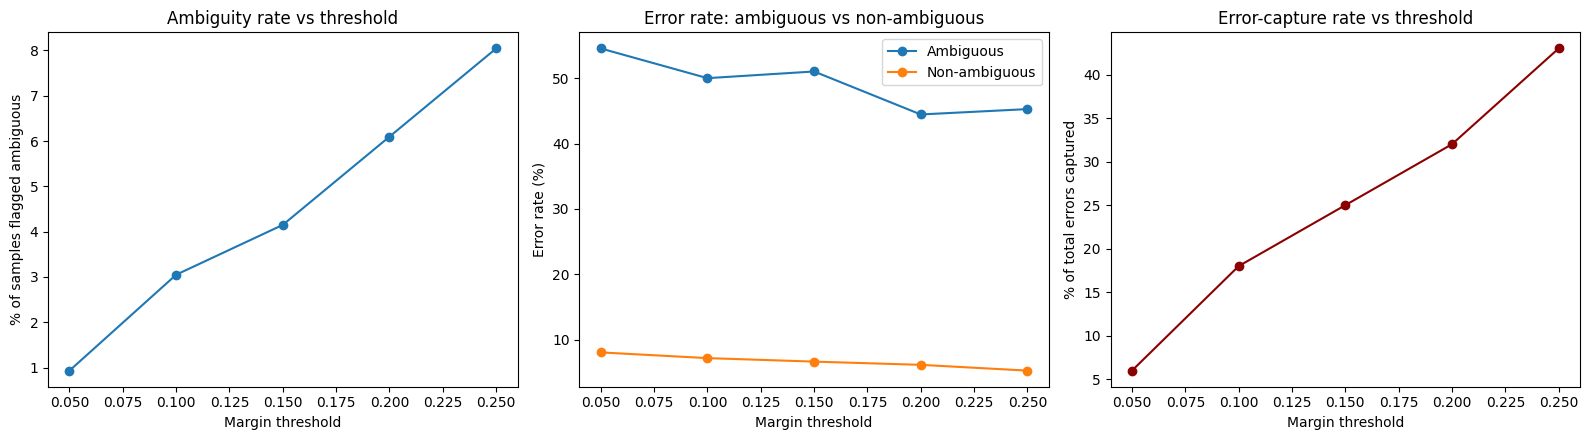

In [ ]:
# %% Cell 5 -- plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(threshold_df["threshold"], threshold_df["ambiguity_pct"], marker="o")
axes[0].set_xlabel("Margin threshold")
axes[0].set_ylabel("% of samples flagged ambiguous")
axes[0].set_title("Ambiguity rate vs threshold")

axes[1].plot(threshold_df["threshold"], threshold_df["error_rate_ambiguous_pct"], marker="o", label="Ambiguous")
axes[1].plot(threshold_df["threshold"], threshold_df["error_rate_nonambiguous_pct"], marker="o", label="Non-ambiguous")
axes[1].set_xlabel("Margin threshold")
axes[1].set_ylabel("Error rate (%)")
axes[1].set_title("Error rate: ambiguous vs non-ambiguous")
axes[1].legend()

axes[2].plot(threshold_df["threshold"], threshold_df["errors_captured_pct"], marker="o", color="darkred")
axes[2].set_xlabel("Margin threshold")
axes[2].set_ylabel("% of total errors captured")
axes[2].set_title("Error-capture rate vs threshold")

plt.tight_layout()
plt.savefig("/content/uncertainty_threshold_plots.png", dpi=150)
plt.show()

In [ ]:
# %% Cell 6 -- explicit threshold-selection analysis
print("\n=== Threshold-selection analysis ===")
print("Trade-off to weigh: a higher threshold flags more samples as ambiguous")
print("(more review burden) but catches a larger share of the model's actual")
print("errors (higher sensitivity for catching mistakes). A lower threshold")
print("flags fewer samples but may miss errors that occurred with a deceptively")
print("confident-looking margin.\n")

for _, row in threshold_df.iterrows():
    print(f"  threshold={row['threshold']:.2f} -> flags {row['ambiguity_pct']:.1f}% of samples "
          f"as ambiguous, capturing {row['errors_captured_pct']:.1f}% of all errors "
          f"(error rate inside flagged group: {row['error_rate_ambiguous_pct']:.1f}%, "
          f"outside: {row['error_rate_nonambiguous_pct']:.1f}%)")

# Pick the smallest threshold that captures at least 50% of errors without
# flagging more than ~30% of all samples as ambiguous -- adjust these two
# bounds to match your actual desired sensitivity/specificity tradeoff.
candidates = threshold_df[(threshold_df["errors_captured_pct"] >= 50) & (threshold_df["ambiguity_pct"] <= 30)]
if len(candidates) > 0:
    CHOSEN_THRESHOLD = candidates.iloc[0]["threshold"]
else:
    CHOSEN_THRESHOLD = threshold_df.iloc[len(threshold_df) // 2]["threshold"]  # fallback: middle value

print(f"\n>>> Selected threshold: {CHOSEN_THRESHOLD} <<<")
print("(Change CHOSEN_THRESHOLD manually below if this auto-pick doesn't match")
print("the sensitivity/specificity tradeoff you actually want.)")

# %% Cell 7 -- lock the threshold, add final column, save CSV + Excel
# CHOSEN_THRESHOLD = 0.15  # <- uncomment and edit to override the auto-pick above

results_df["Ambiguous"] = np.where(
    results_df["margin"] < CHOSEN_THRESHOLD, "Ambiguous", "Non-ambiguous"
)

results_df.to_csv("/content/tabpfn_uncertainty_results.csv", index=False)
results_df.to_excel("/content/tabpfn_uncertainty_results.xlsx", index=False)

print(f"\nSaved: /content/tabpfn_uncertainty_results.csv")
print(f"Saved: /content/tabpfn_uncertainty_results.xlsx")
print(f"\n{results_df['Ambiguous'].value_counts()}")


=== Threshold-selection analysis ===
Trade-off to weigh: a higher threshold flags more samples as ambiguous
(more review burden) but catches a larger share of the model's actual
errors (higher sensitivity for catching mistakes). A lower threshold
flags fewer samples but may miss errors that occurred with a deceptively
confident-looking margin.

  threshold=0.05 -> flags 0.9% of samples as ambiguous, capturing 6.0% of all errors (error rate inside flagged group: 54.5%, outside: 8.0%)
  threshold=0.10 -> flags 3.0% of samples as ambiguous, capturing 18.0% of all errors (error rate inside flagged group: 50.0%, outside: 7.2%)
  threshold=0.15 -> flags 4.1% of samples as ambiguous, capturing 25.0% of all errors (error rate inside flagged group: 51.0%, outside: 6.6%)
  threshold=0.20 -> flags 6.1% of samples as ambiguous, capturing 32.0% of all errors (error rate inside flagged group: 44.4%, outside: 6.1%)
  threshold=0.25 -> flags 8.0% of samples as ambiguous, capturing 43.0% of all errors

In [ ]:
# %% Cell 8 -- performance metrics: full set, non-ambiguous only, ambiguous only
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def print_metrics_block(sub_df, label):
    if len(sub_df) == 0:
        print(f"{label}: no samples in this group")
        return
    acc = accuracy_score(sub_df["y_true"], sub_df["y_pred"])
    p, r, f, _ = precision_recall_fscore_support(
        sub_df["y_true"], sub_df["y_pred"], labels=class_labels, zero_division=0
    )
    print(f"\n--- {label} (n={len(sub_df)}) ---")
    print(f"Accuracy: {acc:.4f}")
    for cls, pi, ri, fi in zip(class_labels, p, r, f):
        print(f"  {cls:6s} | precision={pi:.4f}  recall={ri:.4f}  f1={fi:.4f}")
    print(f"  MACRO  | precision={np.mean(p):.4f}  recall={np.mean(r):.4f}  f1={np.mean(f):.4f}")

print(f"=== Performance metrics at locked threshold = {CHOSEN_THRESHOLD} ===")
print_metrics_block(results_df, "Full dataset (all predictions)")
print_metrics_block(results_df[results_df["Ambiguous"] == "Non-ambiguous"], "Non-ambiguous only")

=== Performance metrics at locked threshold = 0.15 ===

--- Full dataset (all predictions) (n=1181) ---
Accuracy: 0.9153
  ABMR   | precision=0.8987  recall=0.8436  f1=0.8703
  NR     | precision=0.9286  recall=0.9574  f1=0.9427
  TCMR   | precision=0.8442  recall=0.8025  f1=0.8228
  MACRO  | precision=0.8905  recall=0.8678  f1=0.8786

--- Non-ambiguous only (n=1132) ---
Accuracy: 0.9337
  ABMR   | precision=0.9196  recall=0.8767  f1=0.8976
  NR     | precision=0.9444  recall=0.9656  f1=0.9549
  TCMR   | precision=0.8767  recall=0.8421  f1=0.8591
  MACRO  | precision=0.9136  recall=0.8948  f1=0.9038
